<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula01a_perceptron_learning_algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

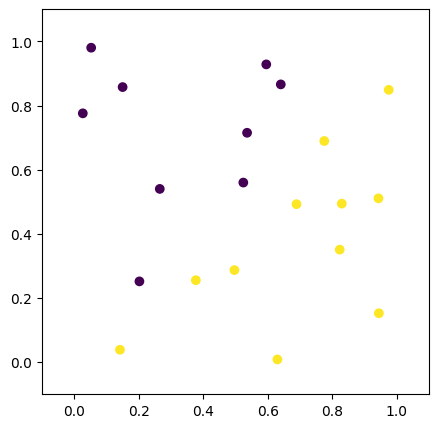

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def createDataset(n=20):
  X = np.random.rand(n,2)
  y = np.array(X[:,0]>X[:,1], dtype=int)*2-1
  return X, y

X, y = createDataset()

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  plt.scatter(X[:,0], X[:,1], c=y)
  plt.xlim(-0.1,1.1)
  plt.ylim(-0.1,1.1)

plotDataset(X, y)
plt.show()

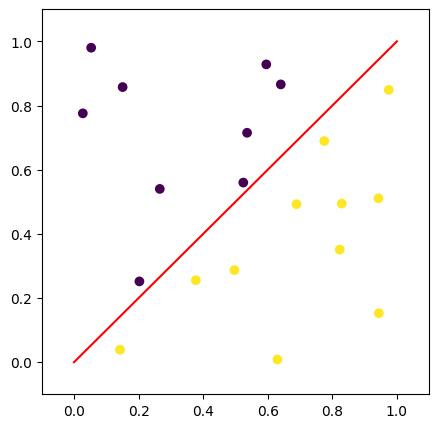

In [8]:
def plotHyperplan(vector):
  xs = np.array([0,1])
  ys = -(vector[0]*xs)/vector[1]
  plt.plot(xs, ys, 'r-')

plotDataset(X, y)
plotHyperplan(np.array([1,-1]))
plt.show()

In [9]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def sign(a):
  return (a>=0)*2-1


class DummyClassifier(BaseEstimator, ClassifierMixin):
  def fit(self, X, y):
    self.w_ = np.array([1,-1])
    return self
  def predict(self, X):
    logits = X @ self.w_
    ypred = sign(logits)
    return ypred

clf = DummyClassifier()
clf.fit(X, y)
ypred = clf.predict(X)
accuracy_score(y, ypred)


1.0

Accuracy: 1.0
Weights: [ 1.47873298 -1.6362326 ]


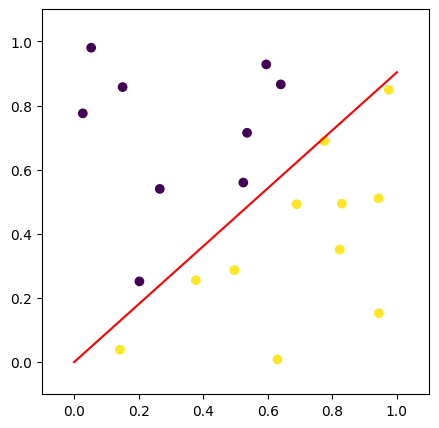

In [24]:
class PLA(BaseEstimator, ClassifierMixin):
  def __init__(self, max_iter=10):
    self.max_iter = max_iter

  def fit(self, X, y):
    self.w_ = np.random.uniform(size=(X.shape[1],))*2-1
    # PLA - Perceptron Learning Algorithm
    for _ in range(self.max_iter):
      cost = 0
      idx = np.arange(X.shape[0])
      np.random.shuffle(idx)
      for i in idx:
        ypred = self.predict(X[i:i+1,:])
        error = y[i]-ypred
        if error != 0:
          cost += error**2
          self.w_ += error*X[i,:]
      if cost == 0:
        break
    return self

  def predict(self, X):
    logits = X @ self.w_
    ypred = sign(logits)
    return ypred

clf = PLA()
clf.fit(X, y)
ypred = clf.predict(X)
print(f"Accuracy: {accuracy_score(y, y)}")
print(f"Weights: {clf.w_}")
plotDataset(X, y)
plotHyperplan(clf.w_)
plt.show()

Accuracy: 0.961


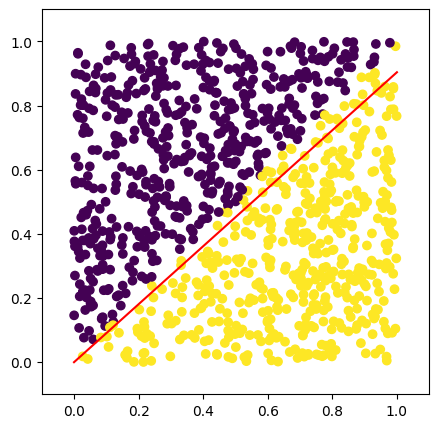

In [26]:
X_test, y_test = createDataset(1000)
ypred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, ypred))
plotDataset(X_test, y_test)
plotHyperplan(clf.w_)
plt.show()